In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import metpy.calc as mpcalc
import numpy as np
import xarray as xr
import glob
import matplotlib.ticker as mticker
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import pandas as pd
import cmocean.cm as cmo

In [2]:
from multiprocessing import Pool
from itertools import product
from itertools import starmap

def mask_insignificant(data1, data2, data1_s, data2_s):
    
    mode1 = np.where(np.sqrt(data1*data1+data2*data2) >= 1 , data1, np.NaN )
    mode2 = np.where(np.sqrt(data1*data1+data2*data2) >= 1, data2, np.NaN )
    
    return mode1, mode2


def grid_mask(m):
    
    mode = mask_insignificant(x[m], y[m], sig_x[m], sig_y[m])
    
    return mode

In [ ]:
# get dataset for SLP and surface wind at ly5
length=6 # -5,....0 year
ly = -5
variable = 'wind_sig'
block_length=2

data_x = xr.open_dataset("/work/uo1075/u241321/data/boot_reg_windx_ly"+str(-ly)+"_block"+str(block_length)+"_bp.nc", decode_times=False)  # unit: m/s
data_y = xr.open_dataset("/work/uo1075/u241321/data/boot_reg_windy_ly"+str(-ly)+"_block"+str(block_length)+"_bp.nc", decode_times=False)

reg_x = data_x['corr']
reg_y = data_y['corr']
reg_x_s = data_x['sig']
reg_y_s = data_y['sig']

data_reg = xr.open_dataset("/work/uo1075/u241321/data/boot_reg_psl_ly"+str(-ly)+"_block"+str(block_length)+"_bp.nc")
psl5 = data_reg['corr']/100  # change the unit to hPa
psl_s5 = data_reg['sig']
lon = reg_x.lon
lat = reg_x.lat
# np.count_nonzero(sig==0)
# np.nanmin(sig)

x = reg_x.stack(spatial=('lat','lon'))
y = reg_y.stack(spatial=('lat','lon'))
sig_x = reg_x_s.stack(spatial=('lat','lon'))
sig_y = reg_y_s.stack(spatial=('lat','lon'))
spatial = x.coords["spatial"]

res = Pool().map(grid_mask,np.arange(0,x.shape[0],1))
re = np.array(res)
# output 
reg_u5 = xr.DataArray(re[:,0], dims = ["spatial"], coords = {"spatial":spatial}).unstack()    
reg_v5 = xr.DataArray(re[:,1], dims = ["spatial"], coords = {"spatial":spatial}).unstack()    

In [ ]:
psl_s5

In [13]:
# get dataset for SLP and surface wind at ly4
length=6 # -5,....0 year
ly = -4
variable = 'wind_sig'
block_length=2

data_x = xr.open_dataset("/work/uo1075/u241321/data/boot_reg_windx_ly"+str(-ly)+"_block"+str(block_length)+"_bp.nc", decode_times=False)  # unit: m/s
data_y = xr.open_dataset("/work/uo1075/u241321/data/boot_reg_windy_ly"+str(-ly)+"_block"+str(block_length)+"_bp.nc", decode_times=False)

reg_x = data_x['corr']
reg_y = data_y['corr']
reg_x_s = data_x['sig']
reg_y_s = data_y['sig']

data_reg = xr.open_dataset("/work/uo1075/u241321/data/boot_reg_psl_ly"+str(-ly)+"_block"+str(block_length)+"_bp.nc")
psl4 = data_reg['corr']/100  # change the unit to hPa
psl_s4 = data_reg['sig']

x = reg_x.stack(spatial=('lat','lon'))
y = reg_y.stack(spatial=('lat','lon'))
sig_x = reg_x_s.stack(spatial=('lat','lon'))
sig_y = reg_y_s.stack(spatial=('lat','lon'))
spatial = x.coords["spatial"]

res = Pool().map(grid_mask,np.arange(0,x.shape[0],1))
re = np.array(res)
# output 
reg_u4 = xr.DataArray(re[:,0], dims = ["spatial"], coords = {"spatial":spatial}).unstack()    
reg_v4 = xr.DataArray(re[:,1], dims = ["spatial"], coords = {"spatial":spatial}).unstack()    

In [14]:
# get dataset for Turbulent flux and zonal wind stress at -5yr
length=6 # -5,....0 year
ly = -5
variable = 'tflux'
block_length=2

data = xr.open_dataset("/work/uo1075/u241321/data/boot_reg_"+variable+"_ly"+str(-ly)+"_block"+str(block_length)+"_bp.nc", decode_times=False)  # unit: m/s

tflux5 = data['corr']
tflux_s5 = data['sig']

variable = 'zwinds'
data = xr.open_dataset("/work/uo1075/u241321/data/boot_reg_"+variable+"_ly"+str(-ly)+"_block"+str(block_length)+"_bp.nc")
zwinds5 = data['corr']
zwinds_s5 = data['sig']

In [15]:
# get dataset for Turbulent flux and zonal wind stress at -4yr
length=6 # -5,....0 year
ly = -4
variable = 'tflux'
block_length=2

data = xr.open_dataset("/work/uo1075/u241321/data/boot_reg_"+variable+"_ly"+str(-ly)+"_block"+str(block_length)+"_bp.nc", decode_times=False)  # unit: m/s

tflux4 = data['corr']
tflux_s4 = data['sig']

variable = 'zwinds'
data = xr.open_dataset("/work/uo1075/u241321/data/boot_reg_"+variable+"_ly"+str(-ly)+"_block"+str(block_length)+"_bp.nc")
zwinds4 = data['corr']
zwinds_s4 = data['sig']

In [17]:
# get dataset for temperature at -5yr
length=6 # -5,....0 year
ly = -5
variable = 't310'
block_length=2

data = xr.open_dataset("/work/uo1075/u241321/data/boot_reg_"+variable+"_ly"+str(-ly)+"_block"+str(block_length)+"_bp.nc", decode_times=False)  # unit: m/s

t3105 = data['corr']
t310_s5 = data['sig']

# get dataset for temperature at -4yr
length=6 # -5,....0 year
ly = -4
variable = 't310'
block_length=2

data = xr.open_dataset("/work/uo1075/u241321/data/boot_reg_"+variable+"_ly"+str(-ly)+"_block"+str(block_length)+"_bp.nc", decode_times=False)  # unit: m/s

t3104 = data['corr']
t310_s4 = data['sig']

# ssh cli
data = xr.open_dataset('/work/uo1075/u241321/data/zos_1970-2019_assi_cli.nc')
ssh = np.mean(data['zos'], axis=0)

/sw/spack-levante/mambaforge-22.9.0-2-Linux-x86_64-kptncg/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1714: UserWarning: The following kwargs were not used by contour: 'add_colorbar', 'add_labels'
  result = matplotlib.axes.Axes.contourf(self, *args, **kwargs)
/sw/spack-levante/mambaforge-22.9.0-2-Linux-x86_64-kptncg/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1714: UserWarning: linewidths is ignored by contourf
  result = matplotlib.axes.Axes.contourf(self, *args, **kwargs)
/sw/spack-levante/mambaforge-22.9.0-2-Linux-x86_64-kptncg/lib/python3.10/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/sw/spack-levante/mambaforge-22.9.0-2-Linux-x86_64-kptncg/lib/python3.10/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle vi

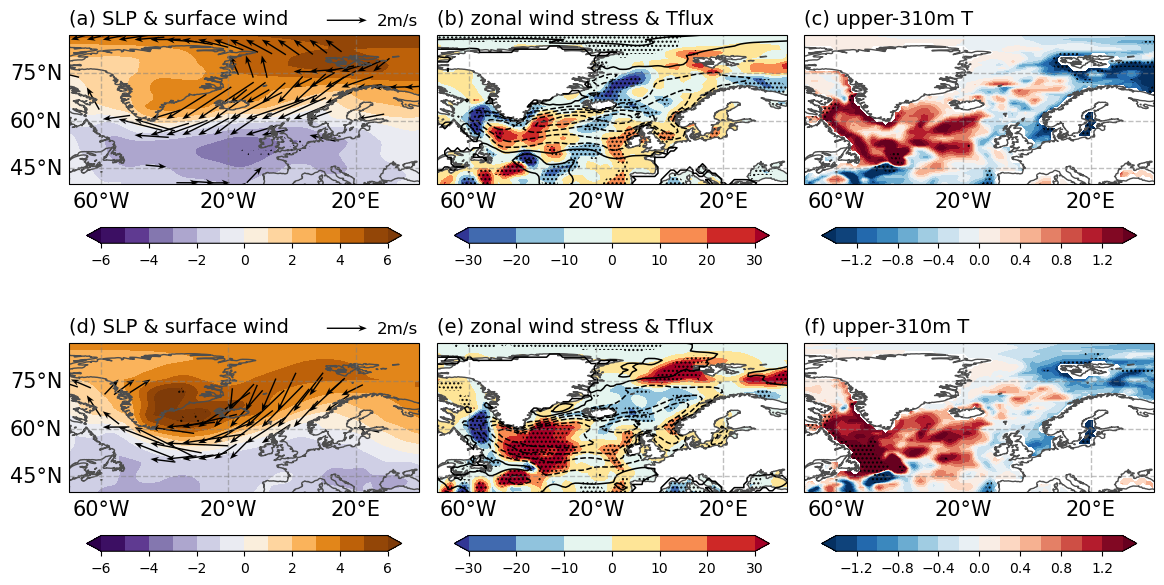

In [19]:
#-- Create the figure
minlat=40
maxlat=85
minlon=-70
maxlon=40
labelsize = 15
xlable = [-60, -20, 20]
ylable = [45,60,75]
title = ["(a) SLP & surface wind","(d) SLP & surface wind","(b) zonal wind stress & Tflux", "(e) zonal wind stress & Tflux",
        "(c) upper-310m T","(f) upper-310m T"]
titlesize = 14
titlepad = 8

projection = ccrs.PlateCarree()

fig = plt.figure(figsize=(14, 8), constrained_layout=False)

#-- Define space for the four plots
gs = fig.add_gridspec(nrows=2, ncols=3, hspace=0, wspace=0.05)

#-- Generate the subplots
ax1 = plt.subplot(gs[0, 0], projection=projection)
ax2 = plt.subplot(gs[1, 0], projection=projection)
ax3 = plt.subplot(gs[0, 1], projection=projection)
ax4 = plt.subplot(gs[1, 1], projection=projection)
ax5 = plt.subplot(gs[0, 2], projection=projection)
ax6 = plt.subplot(gs[1, 2], projection=projection)

################################################################################################
# plot 1: SLP and surface wind at -5yr
################################################################################################

# p1 = ssh[0].plot.contourf(ax=ax1, x='lon', y='lat',levels = np.arange(-6, 7, 1),  
#                               cmap='RdBu_r',
#                               extend = 'both', add_colorbar=False, add_labels=False)
plot = ax1.contourf(lon, lat, psl5, levels = np.arange(-6, 7, 1),  
                              cmap='PuOr_r',
                              extend = 'both', add_colorbar=False, add_labels=False)

plot_s = ax1.contourf(lon, lat, abs(psl_s5),
                      [0, 0.5, 1.1],
                      hatches=[None, '....', None], linewidths=0.5,
                      colors="none", 
                      transform=ccrs.PlateCarree())


vplot = ax1.quiver( lon[::5], lat[::5], reg_u5[::5,::5], reg_v5[::5,::5], width = 0.004, headwidth = 4.5, headlength = 6,pivot = 'tip',scale = 5, scale_units = 'inches')  # ,
ax1.quiverkey(vplot, 0.85, 1.1, 2, "2m/s",labelpos='E', coordinates='axes', fontproperties={'size': 12,'family':'Times New Roman'})

plt.colorbar(plot, ax=ax1, shrink=0.9, pad=0.14, orientation='horizontal')

# ax=ax1
#ax.coastlines()
ax1.add_feature(cfeature.NaturalEarthFeature('physical', 'coastline', '50m',
                                              edgecolor='0.3',
                                              facecolor='none'))
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.xlines = True
gl.ylines = True
ax1.set_extent([minlon,maxlon,minlat,maxlat])
gl.xlocator = mticker.FixedLocator(xlable)
gl.ylocator = mticker.FixedLocator(ylable)
gl.xlabels_top=False
gl.ylabels_right=False


gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': labelsize, 'color': 'k','rotation':0}
gl.ylabel_style = {'size':labelsize,'rotation':0}
ax1.set_title(title[0],size = titlesize, loc = 'left', pad = titlepad)
################################################################################################
# plot 2: SLP and surface wind at -4yr
################################################################################################
 
plot = ax2.contourf(lon, lat, psl4, levels = np.arange(-6, 7, 1),  
                              cmap='PuOr_r',
                              extend = 'both', add_colorbar=False, add_labels=False)

plot_s = ax2.contourf(lon, lat, abs(psl_s4),
                      [0, 0.5, 1.1],
                      hatches=[None, '....', None], linewidths=0.5,
                      colors="none", 
                      transform=ccrs.PlateCarree())

vplot = ax2.quiver( lon[::5], lat[::5], reg_u4[::5,::5], reg_v4[::5,::5], width = 0.004, headwidth = 4.5, headlength = 6,pivot = 'tip',scale = 5, scale_units = 'inches')  # ,
ax1.quiverkey(vplot, 0.85, 1.1, 2, "2m/s",labelpos='E', coordinates='axes', fontproperties={'size': 12,'family':'Times New Roman'})


ax2.add_feature(cfeature.NaturalEarthFeature('physical', 'coastline', '50m',
                                              edgecolor='0.3',
                                              facecolor='none'))
gl = ax2.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='gray', alpha=0.5, linestyle='--')


gl.xlines = True
gl.ylines = True
ax2.set_extent([minlon,maxlon,minlat,maxlat])
gl.xlocator = mticker.FixedLocator(xlable)
gl.ylocator = mticker.FixedLocator(ylable) #([30,60],180)
gl.xlabels_top=False
gl.ylabels_right=False


gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': labelsize, 'color': 'k','rotation':0}
gl.ylabel_style = {'size':labelsize,'rotation':0}
plt.colorbar(plot, ax=ax2, shrink=0.9, pad=0.14, orientation='horizontal')
ax2.set_title(title[1],size = titlesize, loc = 'left', pad = titlepad)

################################################################################################
# plot 3: Turbulent flux and zonal wind stress at -5yr
################################################################################################
 
plot = ax3.contourf(tflux5.lon, tflux5.lat, tflux5, levels = np.arange(-30, 40, 10), 
                              cmap= 'RdYlBu_r',
                              extend = 'both', add_colorbar=False, add_labels=False)

plot_s = ax3.contourf(tflux_s5.lon, tflux_s5.lat, abs(tflux_s5),
                      [0, 0.5, 1.1],
                      hatches=[None, '....', None], linewidths=0.5,
                      colors="none", 
                      transform=ccrs.PlateCarree())

overplot = ax3.contour(zwinds5.lon, zwinds5.lat, zwinds5, negative_linestyles = 'dashed', colors='black',linewidths =1.1 ,
                levels = np.arange(-0.08, 0.1, 0.02))


ax3.add_feature(cfeature.NaturalEarthFeature('physical', 'coastline', '50m',
                                              edgecolor='0.3',
                                              facecolor='1'))
gl = ax3.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='gray', alpha=0.5, linestyle='--')

ax3.set_extent([minlon,maxlon,minlat,maxlat])
gl.xlines = True
gl.ylines = True
gl.xlocator = mticker.FixedLocator(xlable)
gl.ylocator = mticker.FixedLocator(ylable) #([30,60],180)
gl.xlabels_top=False
gl.ylabels_right=False
gl.ylabels_left=False


gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': labelsize, 'color': 'k','rotation':0}
gl.ylabel_style = {'size':labelsize,'rotation':0}
plt.colorbar(plot, ax=ax3, shrink=0.9, pad=0.14, orientation='horizontal')
ax3.set_title(title[2],size = titlesize, loc = 'left', pad = titlepad)
    

################################################################################################
# plot 4: Turbulent flux and zonal wind stress at -4yr
################################################################################################
 
plot = ax4.contourf(tflux4.lon, tflux4.lat, tflux4, levels = np.arange(-30, 40, 10), 
                              cmap= 'RdYlBu_r',
                              extend = 'both', add_colorbar=False, add_labels=False)

plot_s = ax4.contourf(tflux_s4.lon, tflux_s4.lat, abs(tflux_s4),
                      [0, 0.5, 1.1],
                      hatches=[None, '....', None], linewidths=0.5,
                      colors="none", 
                      transform=ccrs.PlateCarree())

overplot = ax4.contour(zwinds4.lon, zwinds4.lat, zwinds4, negative_linestyles = 'dashed', colors='black',linewidths =1.1 ,
                levels = np.arange(-0.08, 0.1, 0.02))


ax4.add_feature(cfeature.NaturalEarthFeature('physical', 'coastline', '50m',
                                              edgecolor='0.3',
                                              facecolor='1'))
gl = ax4.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='gray', alpha=0.5, linestyle='--')

ax4.set_extent([minlon,maxlon,minlat,maxlat])
gl.xlines = True
gl.ylines = True
gl.xlocator = mticker.FixedLocator(xlable)
gl.ylocator = mticker.FixedLocator(ylable) #([30,60],180)
gl.xlabels_top=False
gl.ylabels_right=False
gl.ylabels_left=False


gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': labelsize, 'color': 'k','rotation':0}
gl.ylabel_style = {'size':labelsize,'rotation':0}
plt.colorbar(plot, ax=ax4, shrink=0.9, pad=0.14, orientation='horizontal')
ax4.set_title(title[3],size = titlesize, loc = 'left', pad = titlepad)

################################################################################################
# plot 5: T310 at -5yr
################################################################################################
 
plot = ax5.contourf(t3105.lon, t3105.lat, t3105, levels = np.arange(-1.4, 1.6, 0.2), 
                              cmap='RdBu_r',
                              extend = 'both', add_colorbar=False, add_labels=False)

plot_s = ax5.contourf(t3105.lon, t3105.lat, abs(t310_s5),
                      [0, 0.5, 1.1],
                      hatches=[None, '....', None], linewidths=0.5,
                      colors="none", 
                      transform=ccrs.PlateCarree())

# overplot = ax5.contour(t3105.lon, t3105.lat, ssh, negative_linestyles = 'dashed', colors='black',linewidths =1.1 ,
#                 levels = np.arange(-1, 1.2, 0.2))


ax5.add_feature(cfeature.NaturalEarthFeature('physical', 'coastline', '50m',
                                              edgecolor='0.3',
                                              facecolor='1'))
gl = ax5.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='gray', alpha=0.5, linestyle='--')

ax5.set_extent([minlon,maxlon,minlat,maxlat])
gl.xlines = True
gl.ylines = True
gl.xlocator = mticker.FixedLocator(xlable)
gl.ylocator = mticker.FixedLocator(ylable) 
gl.xlabels_top=False
gl.ylabels_right=False
gl.ylabels_left=False


gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': labelsize, 'color': 'k','rotation':0}
gl.ylabel_style = {'size':labelsize,'rotation':0}
plt.colorbar(plot, ax=ax5, shrink=0.9, pad=0.14, orientation='horizontal')
ax5.set_title(title[4],size = titlesize, loc = 'left', pad = titlepad)
  
# draw box
# from matplotlib.patches import Rectangle
#     # Get the current reference
# # axes = plt.gca()

# # Create a Rectangle patch
# rect = Rectangle((-0,60),20,16,linewidth=1,edgecolor='black',facecolor='none', zorder = 10) # leftbotoom weith;height
#     # Add the patch to the Axes
# ax5.add_patch(rect)
    
    
################################################################################################
# plot 6: T310 at -4yr
################################################################################################
 
plot = ax6.contourf(t3104.lon, t3104.lat, t3104, levels = np.arange(-1.4, 1.6, 0.2), 
                              cmap='RdBu_r',
                              extend = 'both', add_colorbar=False, add_labels=False)

plot_s = ax6.contourf(t310_s4.lon, t310_s4.lat, abs(t310_s4),
                      [0, 0.5, 1.1],
                      hatches=[None, '....', None], linewidths=0.5,
                      colors="none", 
                      transform=ccrs.PlateCarree())

# overplot = ax6.contour(t3105.lon, t3105.lat, ssh, negative_linestyles = 'dashed', colors='black',linewidths =1.1 ,
#                 levels = np.arange(-1, 1.2, 0.2))


ax6.add_feature(cfeature.NaturalEarthFeature('physical', 'coastline', '50m',
                                              edgecolor='0.3',
                                              facecolor='1'))
gl = ax6.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='gray', alpha=0.5, linestyle='--')

ax6.set_extent([minlon,maxlon,minlat,maxlat])
gl.xlines = True
gl.ylines = True
gl.xlocator = mticker.FixedLocator(xlable)
gl.ylocator = mticker.FixedLocator(ylable) 
gl.xlabels_top=False
gl.ylabels_right=False
gl.ylabels_left=False


gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': labelsize, 'color': 'k','rotation':0}
gl.ylabel_style = {'size':labelsize,'rotation':0}
plt.colorbar(plot, ax=ax6, shrink=0.9, pad=0.14, orientation='horizontal')
ax6.set_title(title[5],size = titlesize, loc = 'left', pad = titlepad)



fig.savefig('/work/uo1075/u241321/results/p3_spg_response_bp.pdf')    